# Preprocessing

### Outline
- Case Folding (Uppercase to Lowercase)
- Removing Noise (URLs, HTML tags, special characters, numbers)
- Tokenization
- Stopword Removal (before & after comparison)
- Lemmatization (root words / kata dasar)

## 1. Import Libraries & Load Data

In [ ]:
# Install required libraries (run once)
!pip install pandas nltk sastrawi matplotlib seaborn wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Indonesian stemmer (for Bahasa Indonesia articles if applicable)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print('All libraries loaded successfully.')

[nltk_data] Downloading package punkt to /home/lenovo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/lenovo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/lenovo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/lenovo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/lenovo/nltk_data...


All libraries loaded successfully.


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/lenovo/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [2]:
df = pd.read_csv('../dataset/dataset.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 1001 rows, 4 columns
Columns: ['URL', 'Judul', 'Konten', 'Manual Sentiment']


,URL,Judul,Konten,Manual Sentiment
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive


## 2. Initial Data Exploration

In [3]:
df.columns = df.columns.str.strip().str.lower()

print('Column names after standardization:', list(df.columns))
print()
print(df.info())

Column names after standardization: ['url', 'judul', 'konten', 'manual sentiment']

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   url               1001 non-null   str  
 1   judul             1001 non-null   str  
 2   konten            1001 non-null   str  
 3   manual sentiment  1001 non-null   str  
dtypes: str(4)
memory usage: 4.3 MB
None


In [4]:
# Basic statistics
print('=== Dataset Overview ===')
print(f'Total articles     : {len(df)}')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'Missing values per column:')
print(df.isnull().sum())
print()

# Content length distribution
df['konten_length'] = df['konten'].astype(str).apply(len)
df['konten_word_count'] = df['konten'].astype(str).apply(lambda x: len(x.split()))

print(f'Content length (characters) - min: {df["konten_length"].min()}, '
      f'max: {df["konten_length"].max()}, '
      f'mean: {df["konten_length"].mean():.0f}')
print(f'Content word count - min: {df["konten_word_count"].min()}, '
      f'max: {df["konten_word_count"].max()}, '
      f'mean: {df["konten_word_count"].mean():.0f}')

=== Dataset Overview ===
Total articles     : 1001
Duplicate rows     : 0
Missing values per column:
url                 0
judul               0
konten              0
manual sentiment    0
dtype: int64

Content length (characters) - min: 154, max: 26287, mean: 4307
Content word count - min: 20, max: 3601, mean: 581


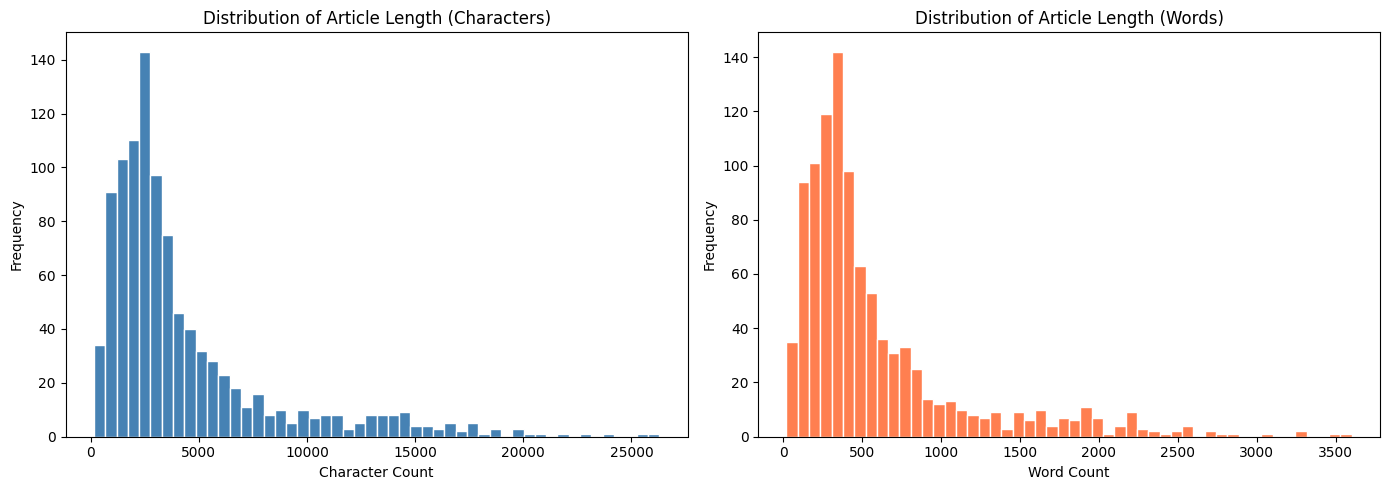

In [5]:
# Visualize content length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['konten_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Article Length (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['konten_word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Article Length (Words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [6]:
# Remove duplicates
before_dedup = len(df)
df = df.drop_duplicates(subset=['konten'], keep='first').reset_index(drop=True)
after_dedup = len(df)
print(f'Removed {before_dedup - after_dedup} duplicate articles.')
print(f'Remaining articles: {after_dedup}')

Removed 2 duplicate articles.
Remaining articles: 999


In [7]:
# Remove rows with missing or empty content

before_clean = len(df)
df = df.dropna(subset=['konten']).reset_index(drop=True)
df = df[df['konten'].astype(str).str.strip() != ''].reset_index(drop=True)
after_clean = len(df)
print(f'Removed {before_clean - after_clean} rows with empty/missing content.')
print(f'Remaining articles: {after_clean}')

Removed 0 rows with empty/missing content.
Remaining articles: 999


## 4. Text Preprocessing Pipeline

The preprocessing pipeline includes:
1. Case folding (uppercase to lowercase)
2. Noise removal (URLs, HTML tags, special characters, extra whitespace)
3. Tokenization
4. Stopword removal
5. Lemmatization

### 4.1 Case Folding (Uppercase to Lowercase)

In [8]:
# Convert all text to lowercase
df['konten_clean'] = df['konten'].astype(str).str.lower()

print('Case folding completed.')
print('\nBefore (sample):')
print(df['konten'].iloc[0][:200])
print('\nAfter (sample):')
print(df['konten_clean'].iloc[0][:200])

Case folding completed.

Before (sample):
Jakarta, CNBC Indonesia -Amerika Serikat (AS) secara resmi memiliki Presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
Presiden Amerika Serikat (AS) Donald Trump resmi dilant

After (sample):
jakarta, cnbc indonesia -amerika serikat (as) secara resmi memiliki presiden baru yang disambut positif karena agenda pro-bisnis yang dibawanya.
presiden amerika serikat (as) donald trump resmi dilant


### 4.2 Noise Removal

In [9]:
def remove_noise(text):
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove single characters (except 'a' and 'i' for English)
    text = re.sub(r'\b[b-hj-z]\b', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['konten_clean'] = df['konten_clean'].apply(remove_noise)

print('Noise removal completed.')
print('\nSample result:')
print(df['konten_clean'].iloc[0][:300])

Noise removal completed.

Sample result:
jakarta cnbc indonesia amerika serikat as secara resmi memiliki presiden baru yang disambut positif karena agenda pro bisnis yang dibawanya presiden amerika serikat as donald trump resmi dilantik pada senin waktu as secara umum dalam pidatonya trump mengungkapkan kebijakan perdagangan proteksionis y


### 4.3 Tokenization

In [10]:
# Tokenize the cleaned text into individual words

df['tokens'] = df['konten_clean'].apply(word_tokenize)

print('Tokenization completed.')
print(f'\nSample tokens (first 20 tokens of first article):')
print(df['tokens'].iloc[0][:20])

Tokenization completed.

Sample tokens (first 20 tokens of first article):
['jakarta', 'cnbc', 'indonesia', 'amerika', 'serikat', 'as', 'secara', 'resmi', 'memiliki', 'presiden', 'baru', 'yang', 'disambut', 'positif', 'karena', 'agenda', 'pro', 'bisnis', 'yang', 'dibawanya']


In [11]:
df['n_tokens_before_stopwords'] = df['tokens'].apply(len)

# Also store the text version before stopword removal
df['text_before_stopwords'] = df['tokens'].apply(lambda x: ' '.join(x))

print('Token counts before stopword removal:')
print(df['n_tokens_before_stopwords'].describe())

Token counts before stopword removal:
count     999.000000
mean      574.209209
std       546.952751
min        18.000000
25%       252.000000
50%       382.000000
75%       683.500000
max      3573.000000
Name: n_tokens_before_stopwords, dtype: float64


### 4.4 Lemmatization

In [ ]:
factory = StemmerFactory()
stemmer_id = factory.create_stemmer()

def stem_tokens_id(tokens):
    """Stem Indonesian tokens using Sastrawi."""
    return [stemmer_id.stem(token) for token in tokens]

df['tokens_lemmatized'] = df['tokens'].apply(stem_tokens_id)

print('Lemmatization completed.')
print(f'\nSample: BEFORE lemmatization (first 15 tokens):')
print(df['tokens'].iloc[0][:15])
print(f'\nSample: AFTER lemmatization (first 15 tokens):')
print(df['tokens_lemmatized'].iloc[0][:15])

In [ ]:
# Create final clean text column from lemmatized tokens

df['konten_preprocessed'] = df['tokens_lemmatized'].apply(lambda x: ' '.join(x))

print('Final preprocessed text created.')
print('\nSample:')
print(df['konten_preprocessed'].iloc[0][:300])

Final preprocessed text created.

Sample:
jakarta cnbc indonesia amerika serikat as cara resmi milik presiden baru yang sambut positif karena agenda pro bisnis yang bawa presiden amerika serikat as donald trump resmi lantik pada senin waktu as cara umum dalam pidato trump ungkap bijak dagang proteksionis yang belum khawatir akan laku cara a


## 5. Top 100 Frequency Words

In [ ]:
all_tokens = [token for tokens_list in df['tokens_lemmatized'] for token in tokens_list]
word_freq = Counter(all_tokens)

# Top 100 words
top_100 = word_freq.most_common(100)

# Create a DataFrame for display
top_100_df = pd.DataFrame(top_100, columns=['Word', 'Frequency'])
top_100_df.index = top_100_df.index + 1  # Start index from 1
top_100_df.index.name = 'Rank'

print(f'Total unique words in corpus: {len(word_freq)}')
print(f'Total words in corpus: {len(all_tokens)}')
print()
print('=== Top 100 Most Frequent Words ===')
print(top_100_df.to_string())

Total unique words in corpus: 13754
Total words in corpus: 573635

=== Top 100 Most Frequent Words ===
           Word  Frequency
Rank                      
1          yang      14589
2           dan      12508
3            as      10591
4         tarif      10172
5            di       7955
6         untuk       6587
7          dari       6569
8           ini       6431
9         trump       6292
10       dengan       6077
11       negara       5911
12         pada       5767
13         akan       5375
14    indonesia       5309
15       dagang       5295
16        dalam       5095
17        china       3808
18        besar       3793
19         jadi       3724
20          itu       3694
21        tidak       3460
22       persen       3445
23           ke       3413
24         juga       3309
25        impor       3288
26        sebut       3282
27      ekonomi       3123
28         laku       3117
29        bijak       3101
30         kata       3092
31        lebih       3037
32    

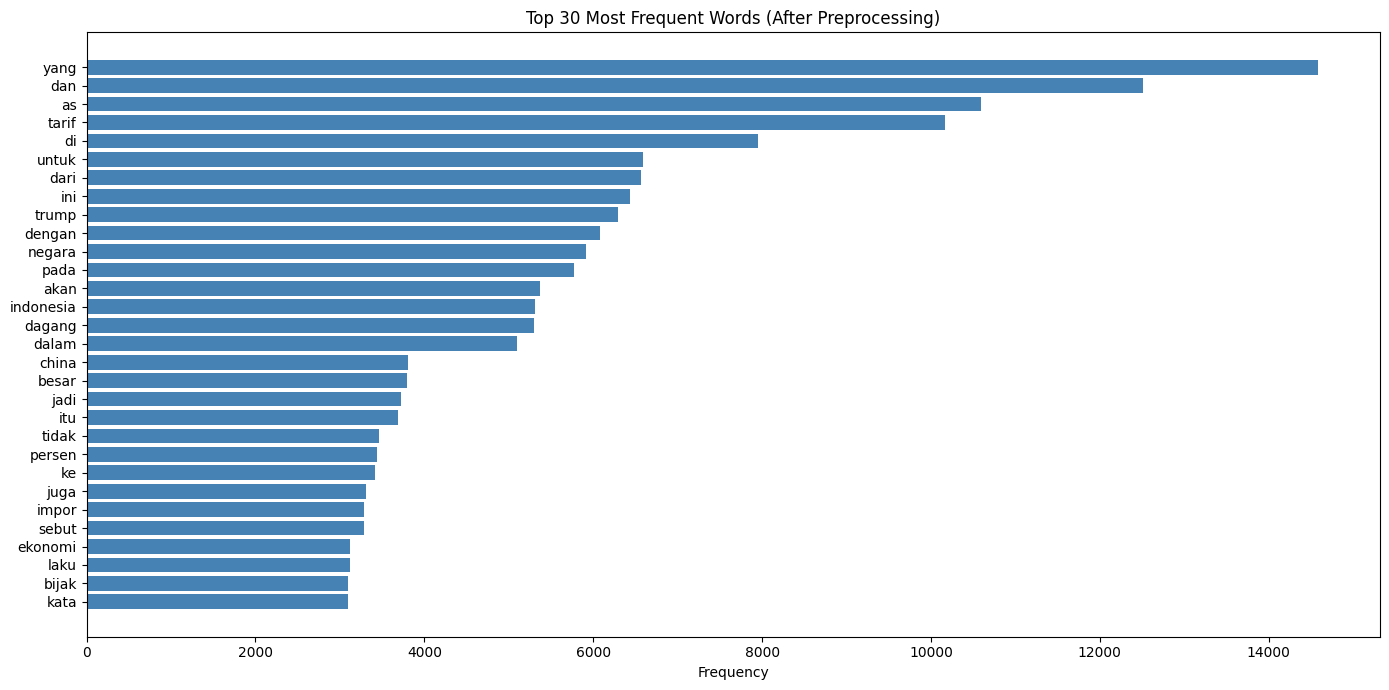

In [ ]:
# Visualization: Top 30 words bar chart

top_30 = top_100_df.head(30)

plt.figure(figsize=(14, 7))
plt.barh(range(len(top_30)), top_30['Frequency'].values, color='steelblue')
plt.yticks(range(len(top_30)), top_30['Word'].values)
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Top 30 Most Frequent Words (After Preprocessing)')
plt.tight_layout()
plt.show()

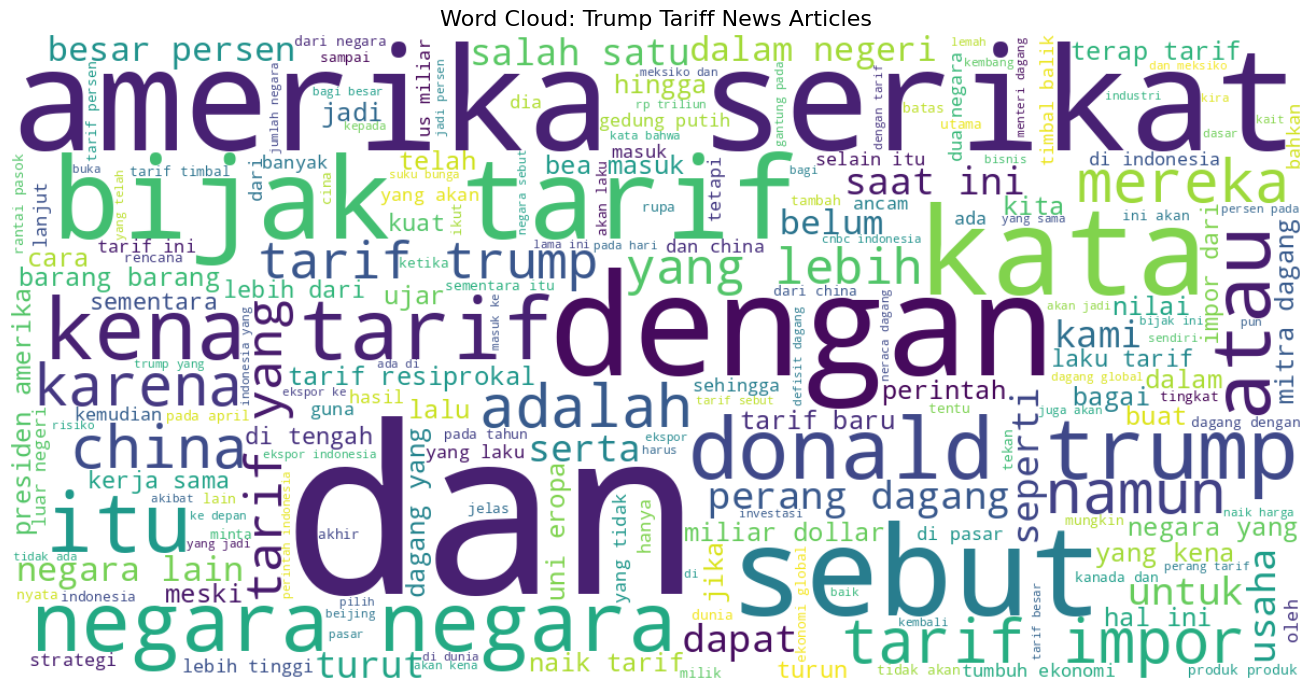

In [ ]:
# Word Cloud visualization

wordcloud_text = ' '.join(all_tokens)
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',
    random_state=42
).generate(wordcloud_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Trump Tariff News Articles', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Export Preprocessed Dataset

In [ ]:
df

,url,judul,konten,manual sentiment,konten_length,konten_word_count,konten_clean,tokens,n_tokens_before_stopwords,text_before_stopwords,tokens_lemmatized,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,1108,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",jakarta cnbc indonesia amerika serikat as cara...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,399,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",jakarta cnbc indonesia nilai tukar rupiah hada...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,1747,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, uang, indone...",jakarta cnbc indonesia pasar uang indonesia ku...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,722,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",jakarta cnbc indonesia indeks harga saham gabu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,616,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, lewat, angka, ting...",hargabitcoin btc pernah lewat angka tinggi di ...
...,...,...,...,...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,506,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, penambang, bi...",499,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, tambang, bitc...",jakarta tiga produsen mesin tambang bitcoin be...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,3319,447,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",448,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",presiden amerika serikat as donald trump aku k...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,627,bisnis com jakarta serangan amerika serikat as...,"[bisnis, com, jakarta, serangan, amerika, seri...",632,bisnis com jakarta serangan amerika serikat as...,"[bisnis, com, jakarta, serang, amerika, serika...",bisnis com jakarta serang amerika serikat as h...
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,387,jakarta cnbc indonesia perusahaan semikondukto...,"[jakarta, cnbc, indonesia, perusahaan, semikon...",386,jakarta cnbc indonesia perusahaan semikonduk

In [ ]:
df_export = df.copy()
df_export.drop(columns=['konten_word_count',	'konten_clean',	'tokens', 'n_tokens_before_stopwords', 'text_before_stopwords',	'tokens_lemmatized'], inplace=True)

df_export.head()

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,jakarta cnbc indonesia amerika serikat as cara...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah hada...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar uang indonesia ku...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,jakarta cnbc indonesia indeks harga saham gabu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc pernah lewat angka tinggi di ...


In [ ]:
df_export.to_csv('../outputs/dataset_preprocessed_bert.csv', index=False, encoding='utf-8')
print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')

Export dataset shape: (999, 6)
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


In [ ]:
df_export

,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,jakarta cnbc indonesia amerika serikat as cara...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah hada...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar uang indonesia ku...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,jakarta cnbc indonesia indeks harga saham gabu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc pernah lewat angka tinggi di ...
...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,3756,jakarta tiga produsen mesin tambang bitcoin be...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,3319,presiden amerika serikat as donald trump aku k...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,4713,bisnis com jakarta serang amerika serikat as h...
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,2830,jakarta cnbc indonesia usaha semikonduktor asa...


In [ ]:
# Select columns to export
export_cols = [
    'url',                         # Original URL
    'judul',                       # Original title
    'konten',                      # Original content (raw)
    # 'konten_clean',                # After case folding + noise removal
    # 'text_before_stopwords',       # Tokenized text before stopwords
    # 'n_tokens_before_stopwords',   # Token count before stopwords
    # 'text_after_stopwords',        # Text after stopword removal
    # 'n_tokens_after_stopwords',    # Token count after stopwords
    'konten_clean',         # Final preprocessed text (lemmatized)
    # 'tokens_lemmatized',           # Lemmatized token list
]

export_cols = [col for col in export_cols if col in df.columns]

df_export = df[export_cols].copy()

if 'tokens_lemmatized' in df_export.columns:
    df_export['tokens_lemmatized'] = df_export['tokens_lemmatized'].apply(
        lambda x: '|'.join(x) if isinstance(x, list) else x
    )

print(f'Export dataset shape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')
df_export.head()

Export dataset shape: (999, 4)
Columns: ['url', 'judul', 'konten', 'konten_clean']


,url,judul,konten,konten_clean
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",jakarta cnbc indonesia pasar keuangan indonesi...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",jakarta cnbc indonesia indeks harga saham gabu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,hargabitcoin btc pernah melewati angka terting...
